# 03 — Multivariate Analysis (Phân tích đa biến)

**Mục tiêu:** Phân tích quan hệ giữa nhiều biến đồng thời — phát hiện đa cộng tuyến,
tương tác giữa các biến, và tổng hợp insight cuối cùng để quyết định Feature Engineering
trước khi bước vào Modeling.

Notebook gồm 4 phần:
1. Setup
2. Ma trận tương quan toàn bộ (Weather x Weather, AQI x AQI) — phát hiện đa cộng tuyến
3. Pairplot / phân tích tương tác giữa nhiều biến theo nhóm AQI Category
4. Tổng hợp Insight → Quyết định Feature Engineering cho Modeling


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

DATA_PATH = "../data/data.csv"
df = pd.read_csv(DATA_PATH, parse_dates=["date"])

def aqi_to_category(value):
    if value <= 50:
        return "Good"
    elif value <= 100:
        return "Moderate"
    elif value <= 150:
        return "Unhealthy for Sensitive Groups"
    elif value <= 200:
        return "Unhealthy"
    elif value <= 300:
        return "Very Unhealthy"
    else:
        return "Hazardous"

df["aqi_category"] = df["us_aqi"].apply(aqi_to_category)
category_order = ["Good", "Moderate", "Unhealthy for Sensitive Groups",
                   "Unhealthy", "Very Unhealthy", "Hazardous"]

df["hour"] = df["date"].dt.hour
df["month"] = df["date"].dt.month
df["season"] = np.where(df["month"].isin([11, 12, 1, 2, 3, 4]), "Mùa khô", "Mùa mưa")

weather_numeric_cols = [
    "temperature_2m", "relative_humidity_2m", "rain", "surface_pressure",
    "cloud_cover", "wind_speed_10m", "wind_direction_10m",
    "sunshine_duration", "boundary_layer_height", "dew_point_2m",
]

print("Shape:", df.shape)


Shape: (263040, 33)


## 2. Ma trận tương quan toàn bộ — phát hiện đa cộng tuyến

### 2.1. Giữa các biến Weather với nhau


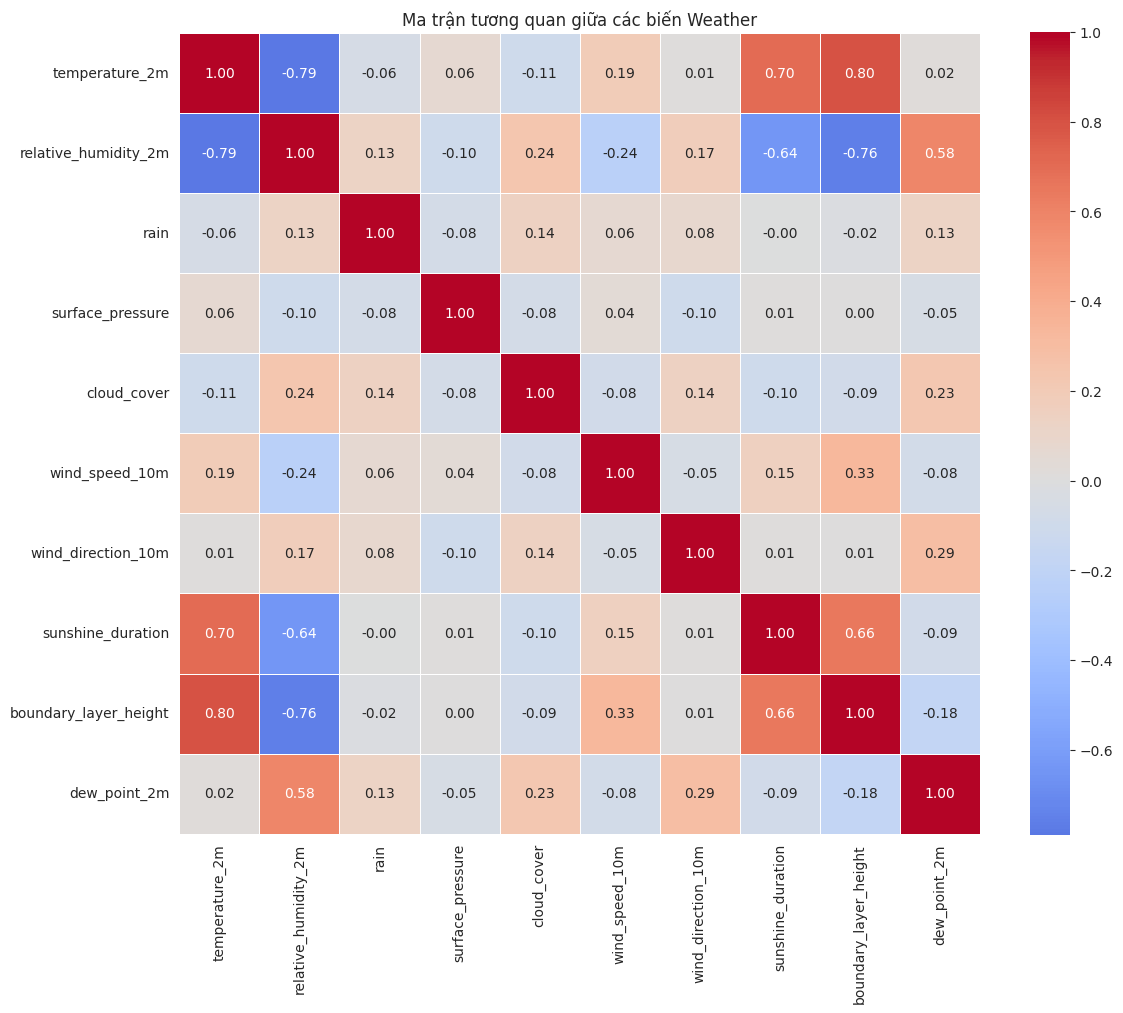

In [2]:
plt.figure(figsize=(12, 10))
corr_weather = df[weather_numeric_cols].corr()
sns.heatmap(corr_weather, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5)
plt.title("Ma trận tương quan giữa các biến Weather")
plt.tight_layout()
plt.show()


In [3]:
# Liệt kê các cặp biến tương quan mạnh (|r| > 0.7) — ứng viên đa cộng tuyến
threshold = 0.7
corr_pairs = []
for i in range(len(corr_weather.columns)):
    for j in range(i + 1, len(corr_weather.columns)):
        r = corr_weather.iloc[i, j]
        if abs(r) > threshold:
            corr_pairs.append((corr_weather.columns[i], corr_weather.columns[j], round(r, 3)))

print(f"Các cặp biến Weather có |tương quan| > {threshold}:")
for pair in corr_pairs:
    print(f"  {pair[0]:<25} <-> {pair[1]:<25}  r = {pair[2]}")
if not corr_pairs:
    print("  Không có cặp nào vượt ngưỡng.")


Các cặp biến Weather có |tương quan| > 0.7:
  temperature_2m            <-> relative_humidity_2m       r = -0.79
  temperature_2m            <-> sunshine_duration          r = 0.701
  temperature_2m            <-> boundary_layer_height      r = 0.8
  relative_humidity_2m      <-> boundary_layer_height      r = -0.757


**Lưu ý nghiệp vụ:** `temperature_2m` và `dew_point_2m` thường tương quan rất cao về bản chất vật lý
(điểm sương phụ thuộc trực tiếp vào nhiệt độ + độ ẩm). Đa cộng tuyến **không ảnh hưởng nhiều**
đến mô hình tree-based (Random Forest, XGBoost) đã định hướng dùng cho bài toán Classification này,
nhưng cần ghi nhận để giải thích model đúng (feature importance có thể bị chia sẻ giữa 2 biến tương quan cao).


### 2.2. Giữa các biến Air Quality với nhau

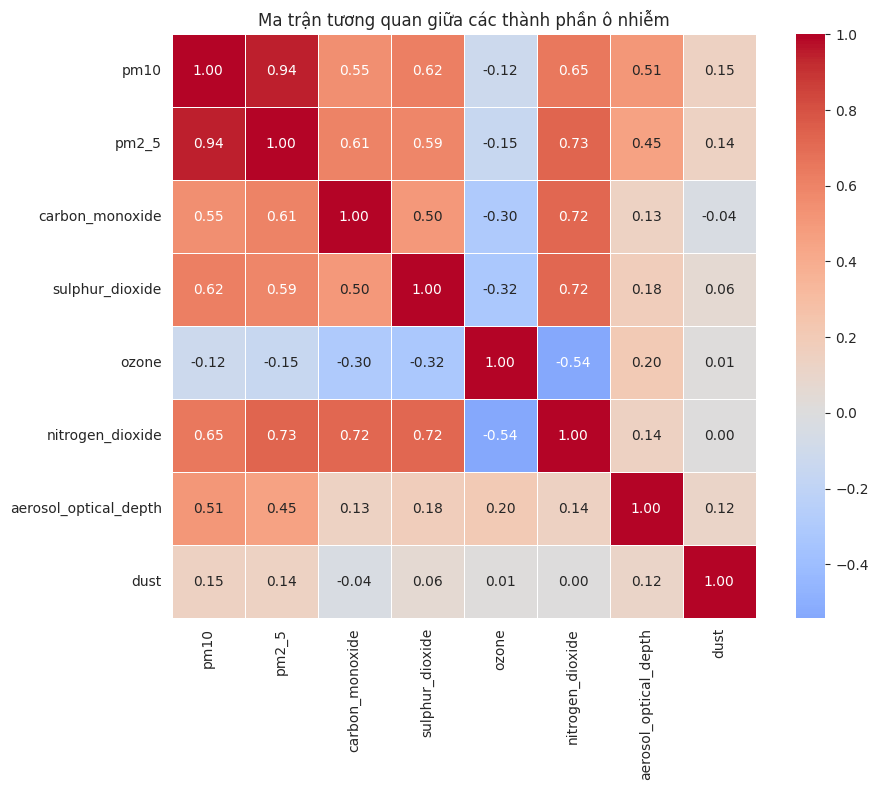

In [4]:
aqi_component_cols = [
    "pm10", "pm2_5", "carbon_monoxide", "sulphur_dioxide", "ozone",
    "nitrogen_dioxide", "aerosol_optical_depth", "dust",
]

plt.figure(figsize=(10, 8))
corr_aqi = df[aqi_component_cols].corr()
sns.heatmap(corr_aqi, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5)
plt.title("Ma trận tương quan giữa các thành phần ô nhiễm")
plt.tight_layout()
plt.show()


## 3. Phân tích tương tác đa biến theo nhóm AQI Category

### 3.1. Scatter: Wind Speed vs Boundary Layer Height, màu theo AQI Category
(2 biến giả thuyết có vai trò khuếch tán ô nhiễm — xem có tương tác rõ với AQI không)


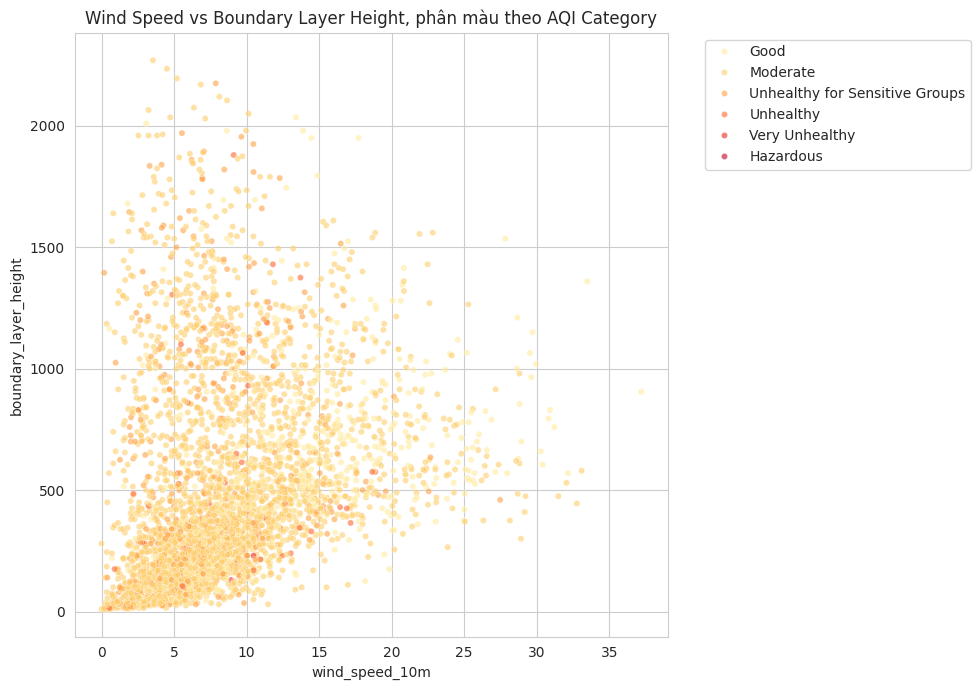

In [5]:
sample_df = df.sample(n=min(5000, len(df)), random_state=42)  # sample để vẽ scatter mượt hơn

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=sample_df, x="wind_speed_10m", y="boundary_layer_height",
    hue="aqi_category", hue_order=category_order, palette="YlOrRd", alpha=0.6, s=20
)
plt.title("Wind Speed vs Boundary Layer Height, phân màu theo AQI Category")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


### 3.2. Pairplot các biến Weather quan trọng nhất, phân màu theo AQI Category

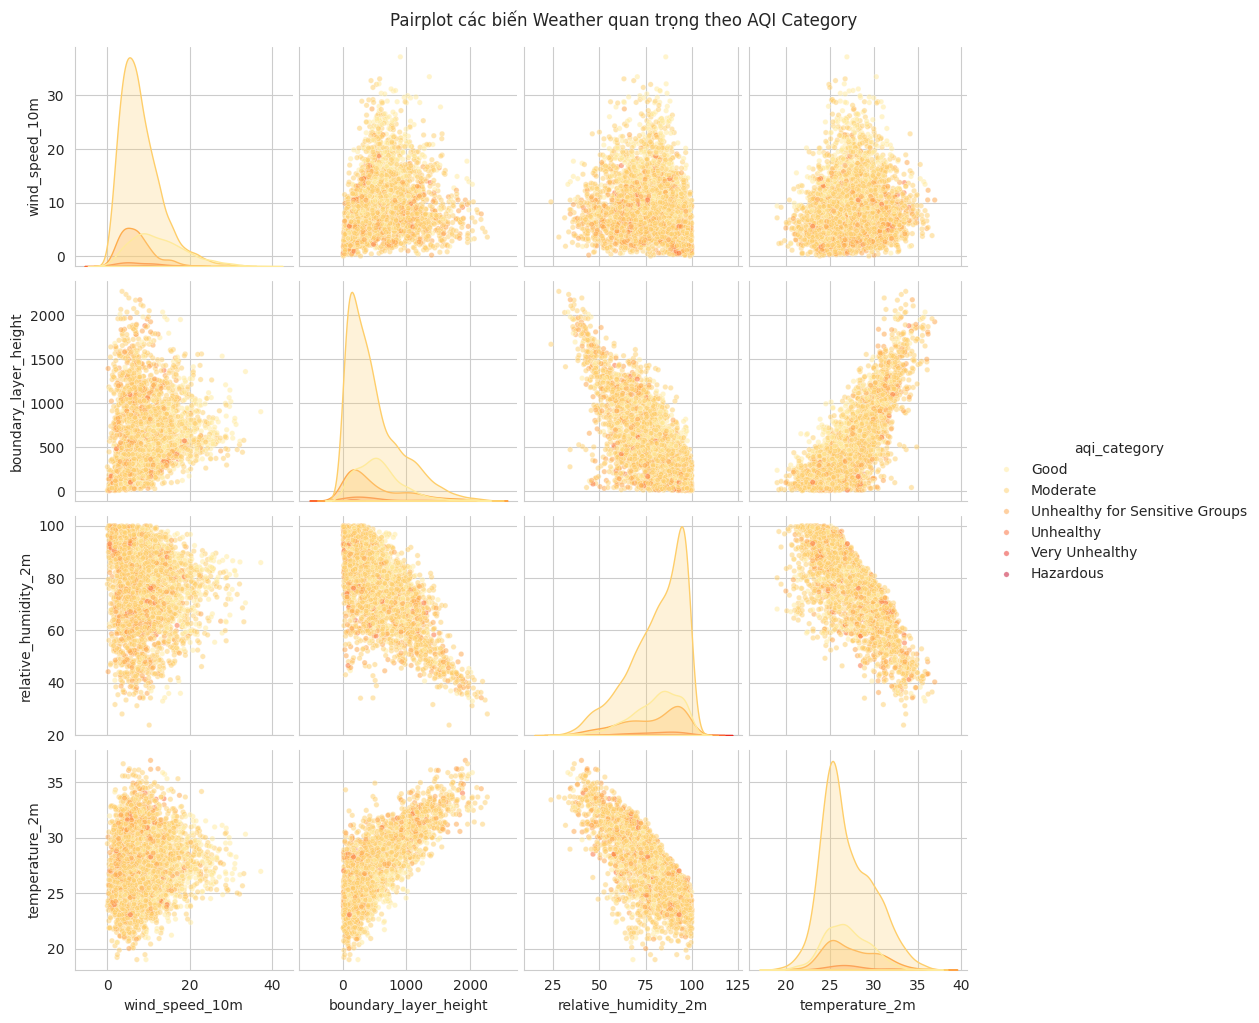

In [6]:
top_vars = ["wind_speed_10m", "boundary_layer_height", "relative_humidity_2m", "temperature_2m"]

pairplot_df = sample_df[top_vars + ["aqi_category"]].dropna()

g = sns.pairplot(
    pairplot_df, hue="aqi_category", hue_order=category_order,
    palette="YlOrRd", diag_kind="kde", plot_kws={"alpha": 0.5, "s": 15}
)
g.fig.suptitle("Pairplot các biến Weather quan trọng theo AQI Category", y=1.02)
plt.show()


### 3.3. Heatmap: AQI trung bình theo (Giờ x Mùa) — tương tác giữa 2 biến thời gian


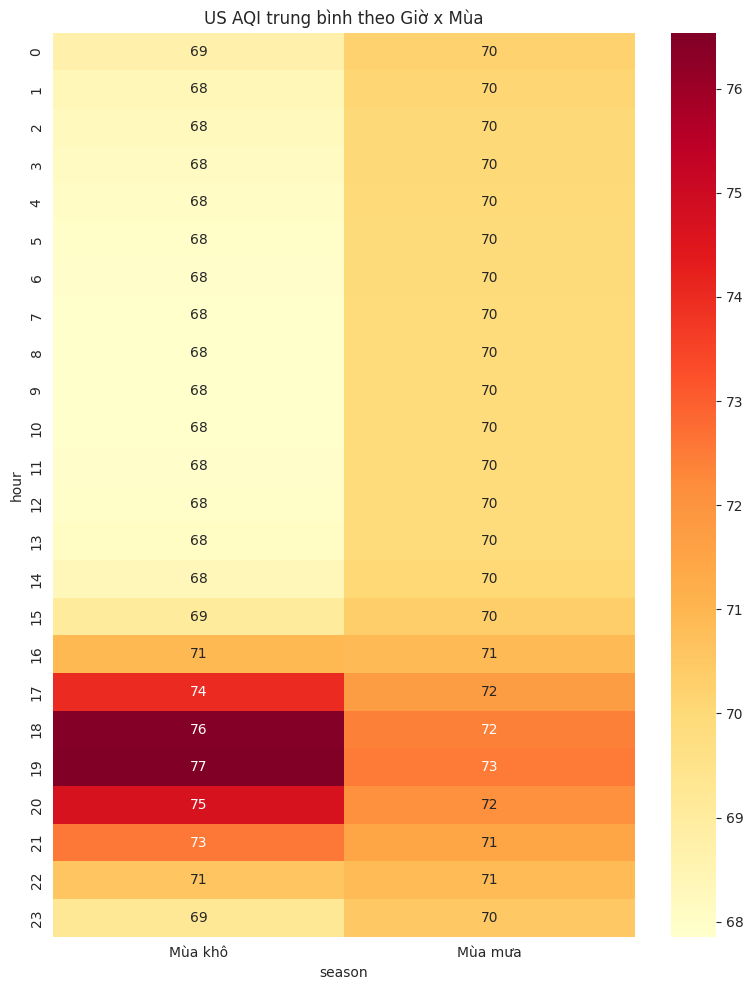

In [7]:
pivot_hour_season = df.pivot_table(values="us_aqi", index="hour", columns="season", aggfunc="mean")

plt.figure(figsize=(8, 10))
sns.heatmap(pivot_hour_season, annot=True, fmt=".0f", cmap="YlOrRd")
plt.title("US AQI trung bình theo Giờ x Mùa")
plt.tight_layout()
plt.show()


### 3.4. Heatmap: AQI trung bình theo (Địa điểm x Mùa)

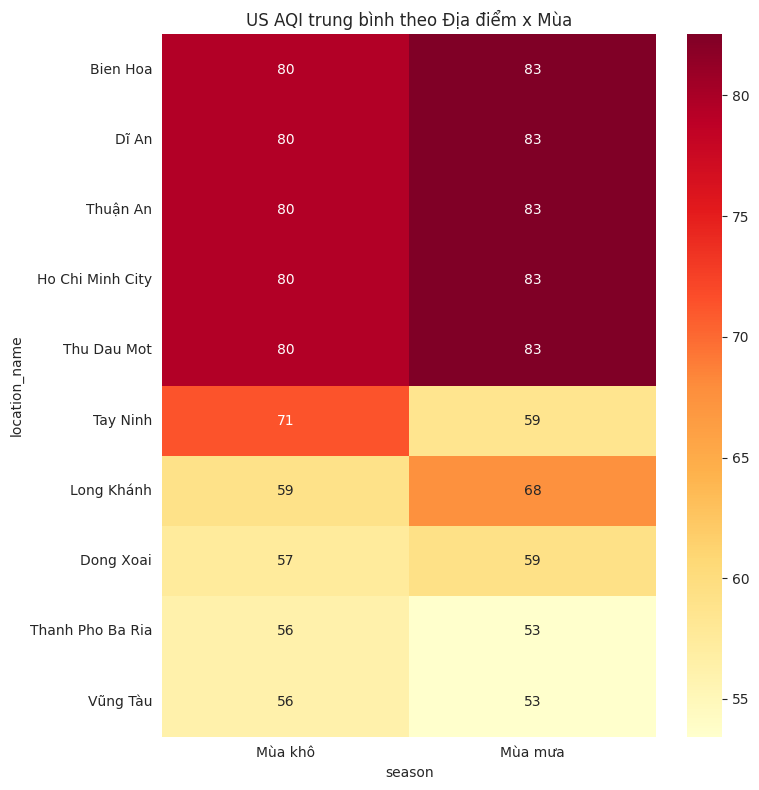

In [8]:
pivot_loc_season = df.pivot_table(values="us_aqi", index="location_name", columns="season", aggfunc="mean")
pivot_loc_season = pivot_loc_season.sort_values("Mùa khô", ascending=False)

plt.figure(figsize=(8, 8))
sns.heatmap(pivot_loc_season, annot=True, fmt=".0f", cmap="YlOrRd")
plt.title("US AQI trung bình theo Địa điểm x Mùa")
plt.tight_layout()
plt.show()


## 4. Tổng hợp Insight → Quyết định Feature Engineering cho Modeling

Điền vào bảng dưới sau khi đã quan sát kết quả ở Notebook 01, 02, 03:


| Câu hỏi | Quyết định |
|---|---|
| Có cần xử lý mất cân bằng lớp không? | _(điền: SMOTE / class_weight='balanced' / cả 2)_ |
| Loại biến nào do đa cộng tuyến quá cao? | _(điền danh sách, hoặc "giữ hết vì dùng tree-based model")_ |
| Feature thời gian nào cần thêm? | `hour`, `season`, `is_weekend` (đã tạo ở notebook này) |
| Feature nào có vẻ ít giá trị dự đoán (ANOVA p-value lớn, tương quan ~0)? | _(điền danh sách)_ |
| Metric đánh giá mô hình | Macro F1-score + Confusion Matrix theo 6 lớp (không chỉ Accuracy, do mất cân bằng lớp) |


In [9]:
# Xuất file feature engineering tạm — sẵn sàng cho bước Modeling
feature_cols = weather_numeric_cols + ["hour", "month", "season"]
target_col = "aqi_category"

modeling_df = df[["location_id", "location_name", "date"] + feature_cols + [target_col, "us_aqi"]].copy()
modeling_df.to_csv("../data/modeling_ready.csv", index=False)

print("Đã xuất modeling_ready.csv, shape:", modeling_df.shape)
modeling_df.head()


Đã xuất modeling_ready.csv, shape: (263040, 18)


,location_id,location_name,date,temperature_2m,relative_humidity_2m,rain,surface_pressure,cloud_cover,wind_speed_10m,wind_direction_10m,sunshine_duration,boundary_layer_height,dew_point_2m,hour,month,season,aqi_category,us_aqi
0,1566083,Ho Chi Minh City,2023-01-01 00:00:00,23.85,61.484700,0.0,1013.40027,100.0,11.304229,9.162280,0.0,70.0,16.0,0,1,Mùa khô,Unhealthy for Sensitive Groups,133.11458
1,1566083,Ho Chi Minh City,2023-01-01 01:00:00,23.30,62.749770,0.0,1013.19920,100.0,10.739833,13.570457,0.0,80.0,15.8,1,1,Mùa khô,Unhealthy for Sensitive Groups,132.65625
2,1566083,Ho Chi Minh City,2023-01-01 02:00:00,22.75,64.459640,0.0,1012.69824,100.0,8.287822,2.489499,0.0,105.0,15.7,2,1,Mùa khô,Unhealthy for Sensitive Groups,131.73958
3,1566083,Ho Chi Minh City,2023-01-01 03:00:00,22.25,65.602090,0.0,1012.29730,100.0,8.669949,4.763556,0.0,135.0,15.5,3,1,Mùa khô,Unhealthy for Sensitive Groups,130.64583
4,1566083,Ho Chi Minh City,2023-01-01 04:00:00,21.95,66.812325,0.0,1012.19680,100.0,7.928178,357.397500,0.0,145.0,15.5,4,1,Mùa khô,Unhealthy for Sensitive Groups,129.43752
